In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'F:\\XLR\\DS\\PROJECT 2 (POWER SUPPLY)\\Power_Analysis'

# 1. EDA

In [3]:
# Loading the Data
df = pd.read_excel("data\PJMW_MW_Hourly.xlsx")
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [4]:
# Basic Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [6]:
# Sorting Values Order of Date

df = df.sort_values('Datetime')

In [7]:
# Setting Index

df.set_index('Datetime', inplace=True)

In [8]:
df.head()

,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374
2002-04-01 02:00:00,4306
2002-04-01 03:00:00,4322
2002-04-01 04:00:00,4359
2002-04-01 05:00:00,4436


In [9]:
df.isnull().sum()

PJMW_MW    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(137863)

In [11]:
df.shape

(143206, 1)

In [12]:
df.duplicated(keep=False).sum()

np.int64(142788)

In [13]:
df.index.duplicated().sum()

np.int64(4)

In [14]:
df = df[~df.index.duplicated(keep='first')]

In [15]:
df['PJMW_MW'] = pd.to_numeric(df['PJMW_MW'], errors='coerce')

In [16]:
df.dtypes

PJMW_MW    int64
dtype: object

In [17]:
df.shape
df.describe()

,PJMW_MW
count,143202.000000
mean,5602.415825
std,979.125030
min,487.000000
25%,4907.000000
50%,5530.000000
75%,6252.000000
max,9594.000000


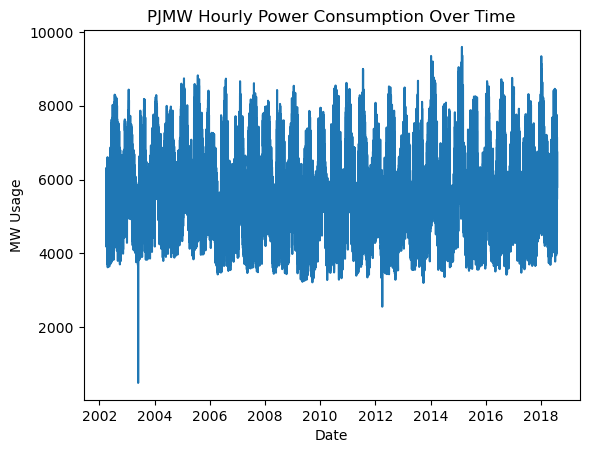

In [18]:
# Time Series Plot

plt.plot(df.index, df.iloc[:,0])
plt.title("PJMW Hourly Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("MW Usage")
plt.show()

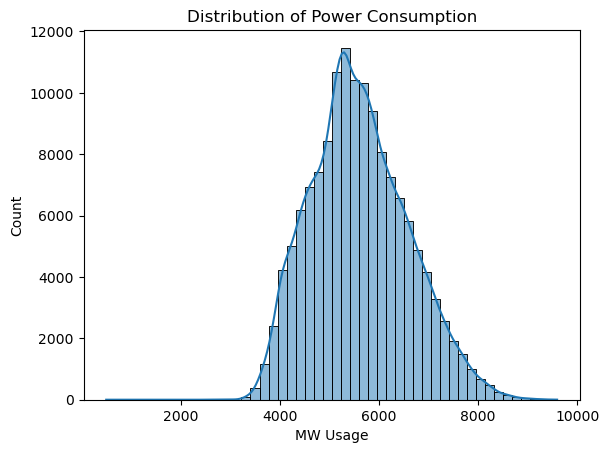

In [19]:
 # Distribution Plot

sns.histplot(df.iloc[:,0], bins=50, kde=True)
plt.title("Distribution of Power Consumption")
plt.xlabel("MW Usage")
plt.show()

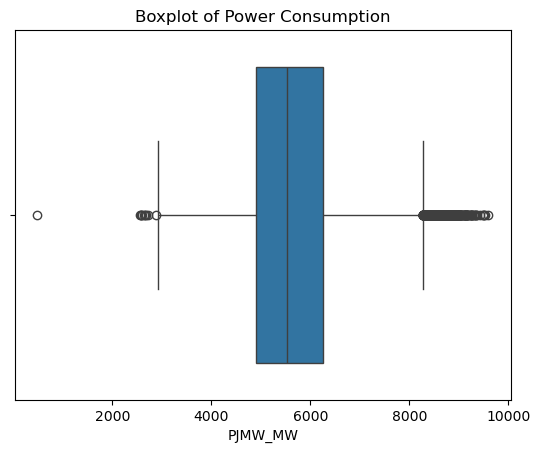

In [20]:
# Boxplot (Outlier Detection)

sns.boxplot(x=df.iloc[:,0])
plt.title("Boxplot of Power Consumption")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\295445181.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample('M').mean()


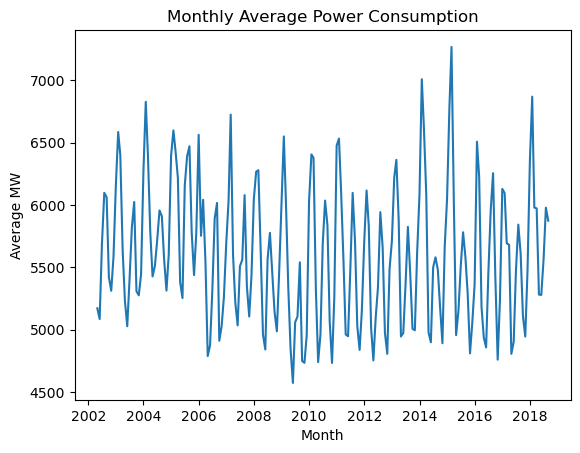

In [21]:
#  Monthly Trend Visualization

monthly_avg = df.resample('M').mean()

plt.plot(monthly_avg.index, monthly_avg.iloc[:,0])
plt.title("Monthly Average Power Consumption")
plt.xlabel("Month")
plt.ylabel("Average MW")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\1944159549.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = df.resample('Y').mean()


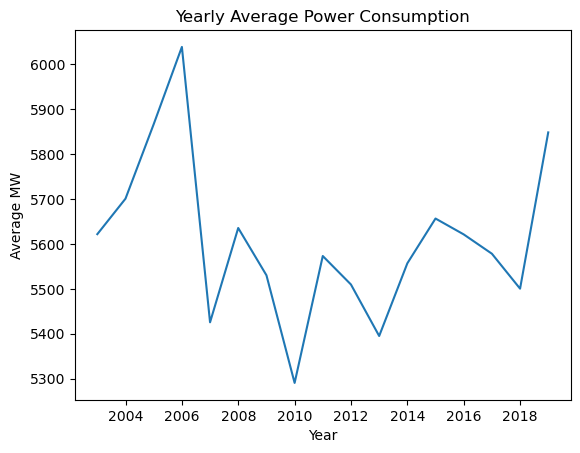

In [22]:
# Yearly Trend

yearly_avg = df.resample('Y').mean()

plt.plot(yearly_avg.index, yearly_avg.iloc[:,0])
plt.title("Yearly Average Power Consumption")
plt.xlabel("Year")
plt.ylabel("Average MW")
plt.show()

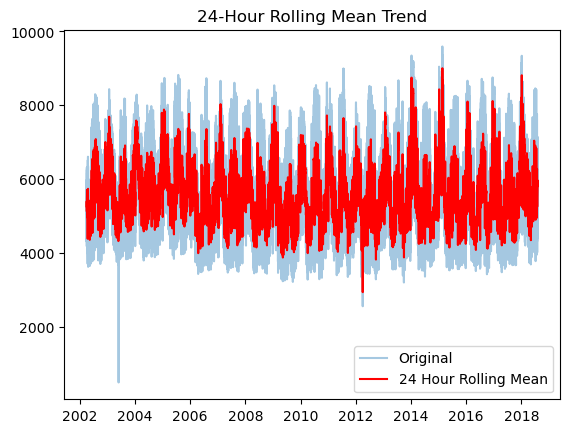

In [23]:
# Rolling Mean (Trend Visualization Only)

rolling_mean = df.iloc[:,0].rolling(window=24).mean()

plt.plot(df.index, df.iloc[:,0], alpha=0.4, label="Original")
plt.plot(df.index, rolling_mean, color='red', label="24 Hour Rolling Mean")
plt.legend()
plt.title("24-Hour Rolling Mean Trend")
plt.show()

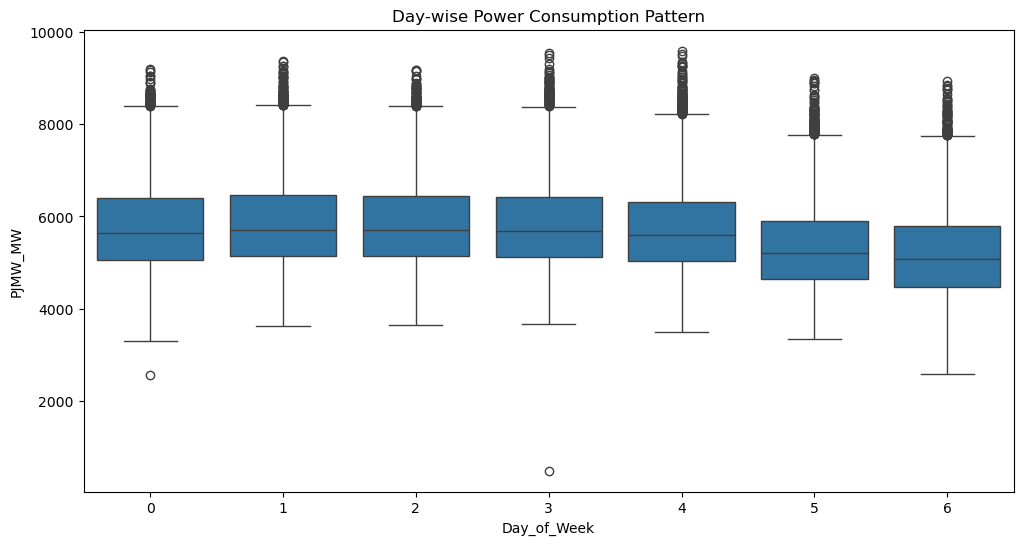

In [24]:
df['Day_of_Week'] = df.index.dayofweek

plt.figure(figsize=(12,6))
sns.boxplot(x='Day_of_Week', y=df.columns[0], data=df)
plt.title("Day-wise Power Consumption Pattern")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2533950617.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample('M').mean()


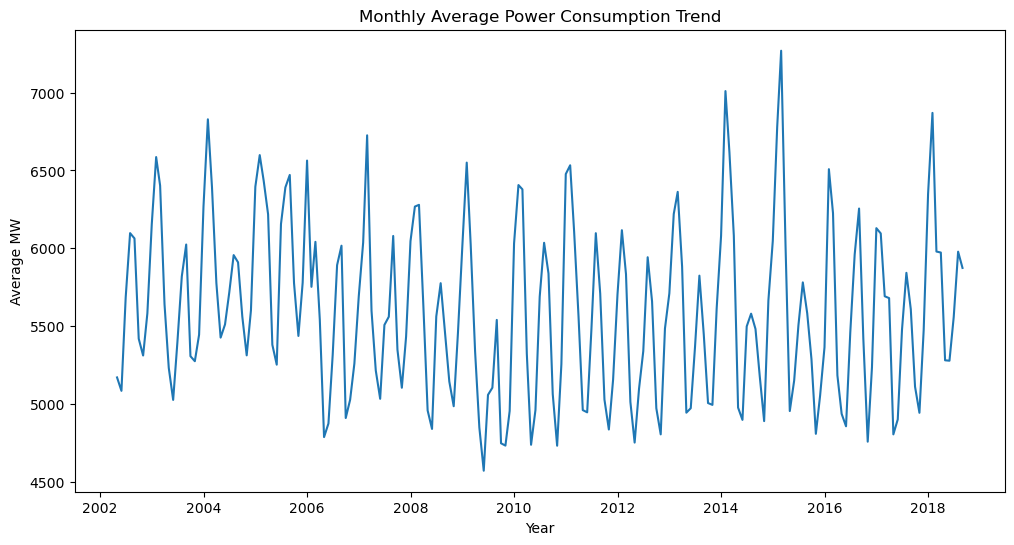

In [25]:
monthly_avg = df.resample('M').mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_avg.index, monthly_avg['PJMW_MW'])
plt.title("Monthly Average Power Consumption Trend")
plt.xlabel("Year")
plt.ylabel("Average MW")
plt.show()

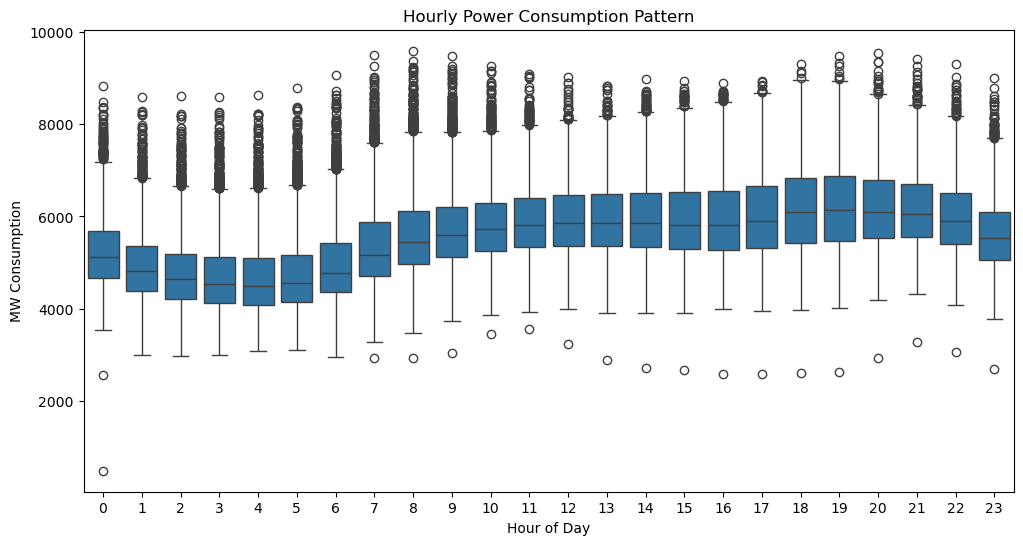

In [26]:
df['Hour'] = df.index.hour

plt.figure(figsize=(12,6))
sns.boxplot(x='Hour', y='PJMW_MW', data=df)
plt.title("Hourly Power Consumption Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("MW Consumption")
plt.show()

In [27]:
df['Month'] = df.index.month

# Define Summer (Jun-Aug) and Winter (Dec-Feb)
df['Season'] = df['Month'].apply(lambda x:
                                  'Summer' if x in [6,7,8]
                                  else 'Winter' if x in [12,1,2]
                                  else 'Other')

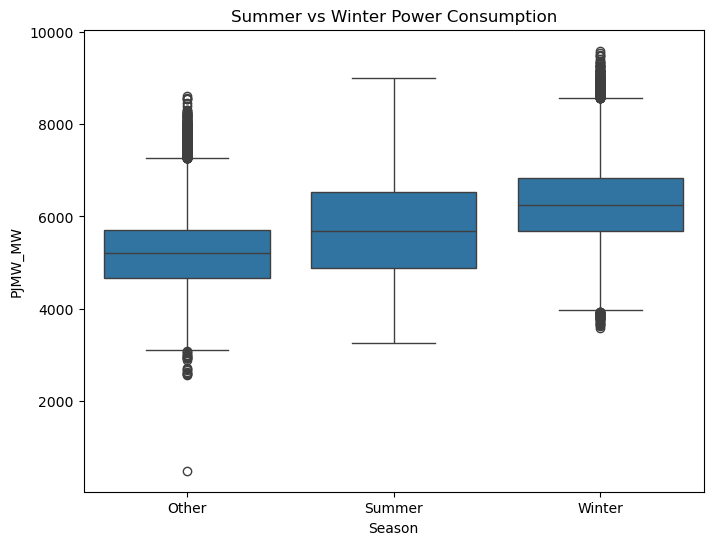

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Season', y='PJMW_MW', data=df)
plt.title("Summer vs Winter Power Consumption")
plt.show()

In [29]:
df['Day_of_Week'] = df.index.dayofweek

df['Day_Type'] = df['Day_of_Week'].apply(lambda x:
                                         'Weekend' if x >= 5
                                         else 'Weekday')

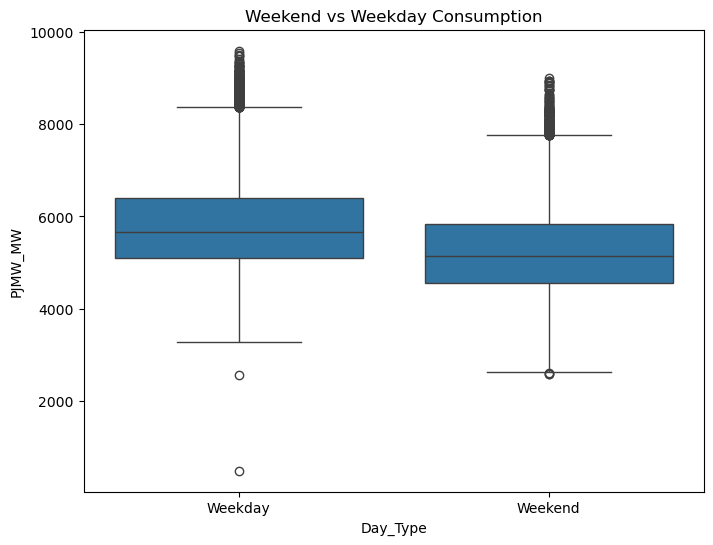

In [30]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Day_Type', y='PJMW_MW', data=df)
plt.title("Weekend vs Weekday Consumption")
plt.show()

In [31]:
df['Hour'] = df.index.hour
df['Month'] = df.index.month

In [32]:
heatmap_data = df.pivot_table(
    values='PJMW_MW',
    index='Month',
    columns='Hour',
    aggfunc='mean'
)

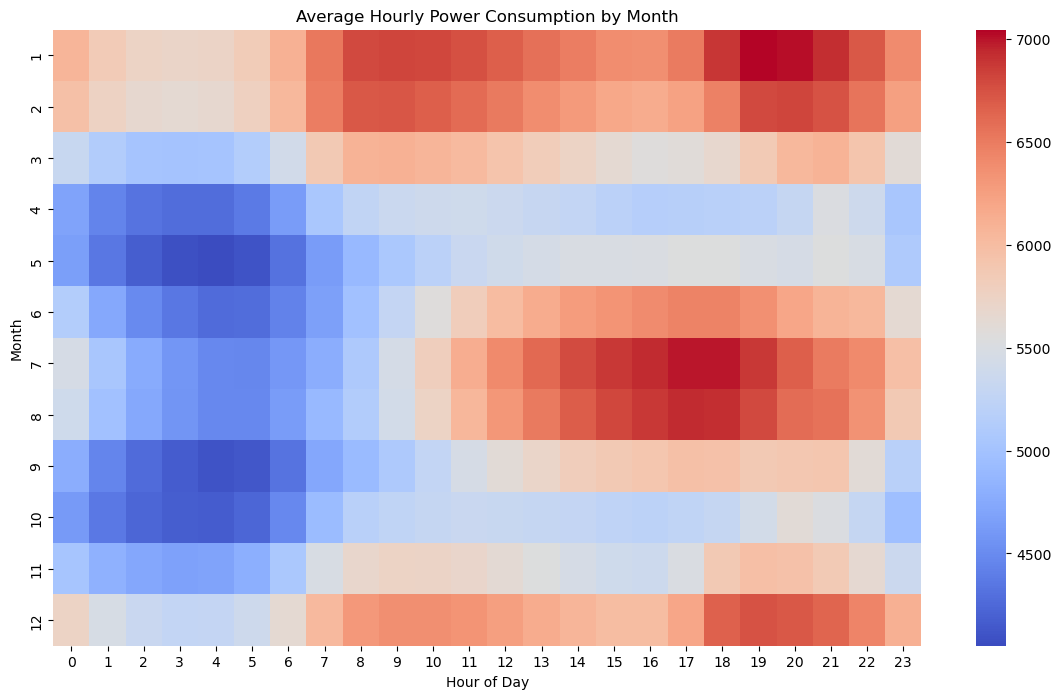

In [33]:
plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap='coolwarm')
plt.title("Average Hourly Power Consumption by Month")
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.show()

In [34]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['PJMW_MW'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -19.88693681297983
p-value: 0.0
Critical Values:
   1%: -3.4303956896133108
   5%: -2.8615601941603197
   10%: -2.5667807486332133


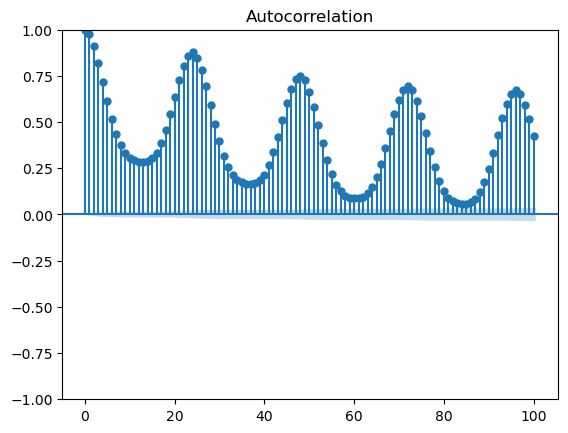

In [35]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['PJMW_MW'], lags=100)
plt.show()

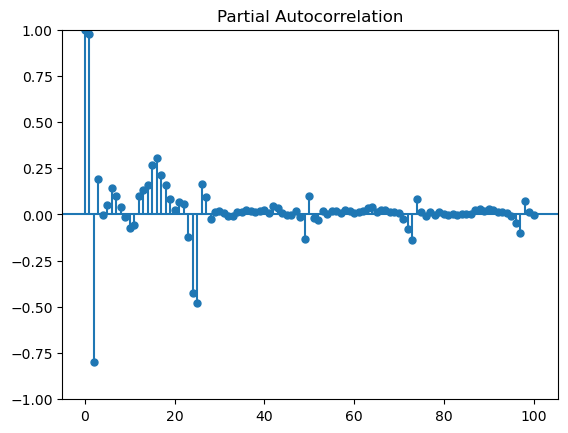

In [36]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['PJMW_MW'], lags=100)
plt.show()

- The series is stationary based on ADF test (p < 0.05).

- ACF shows strong cyclical pattern with significant spikes at lag 24 and multiples, indicating daily seasonality.

- PACF shows significant early lags suggesting low-order AR components.

>Therefore, seasonal modeling techniques such as SARIMA are appropriate.

# 2. Model Building

In [37]:
df.head()

,PJMW_MW,Day_of_Week,Hour,Month,Season,Day_Type
Datetime,,,,,,
2002-04-01 01:00:00,4374,0,1,4,Other,Weekday
2002-04-01 02:00:00,4306,0,2,4,Other,Weekday
2002-04-01 03:00:00,4322,0,3,4,Other,Weekday
2002-04-01 04:00:00,4359,0,4,4,Other,Weekday
2002-04-01 05:00:00,4436,0,5,4,Other,Weekday


In [38]:
df = df.drop(columns=['Season'])

In [39]:
df['Day_Type'] = df['Day_Type'].map({'Weekday': 0, 'Weekend': 1})

In [40]:
df.head()

,PJMW_MW,Day_of_Week,Hour,Month,Day_Type
Datetime,,,,,
2002-04-01 01:00:00,4374,0,1,4,0
2002-04-01 02:00:00,4306,0,2,4,0
2002-04-01 03:00:00,4322,0,3,4,0
2002-04-01 04:00:00,4359,0,4,4,0
2002-04-01 05:00:00,4436,0,5,4,0


In [41]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00


In [42]:
train = df.iloc[:-365*24]
test = df.iloc[-365*24:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (134442, 5)
Test shape: (8760, 5)


# Model 1: ARIMA (Baseline Model)

• ARIMA (AutoRegressive Integrated Moving Average) is a statistical model used for time series forecasting based on past values and past errors.  
• It is useful for capturing short-term patterns and trends in stationary time series data.

In [43]:
from statsmodels.tsa.arima.model import ARIMA

train_series = train['PJMW_MW']
test_series = test['PJMW_MW']

model_arima = ARIMA(
    train_series,
    order=(2,0,2),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                PJMW_MW   No. Observations:               134442
Model:                 ARIMA(2, 0, 2)   Log Likelihood             -845729.309
Date:                Fri, 13 Mar 2026   AIC                        1691470.618
Time:                        20:57:16   BIC                        1691529.471
Sample:                             0   HQIC                       1691488.244
                             - 134442                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5595.9912      9.538    586.706      0.000    5577.297    5614.685
ar.L1          1.6433      0.003    508.052      0.000       1.637       1.650
ar.L2         -0.6927      0.003   -221.665      0.0

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


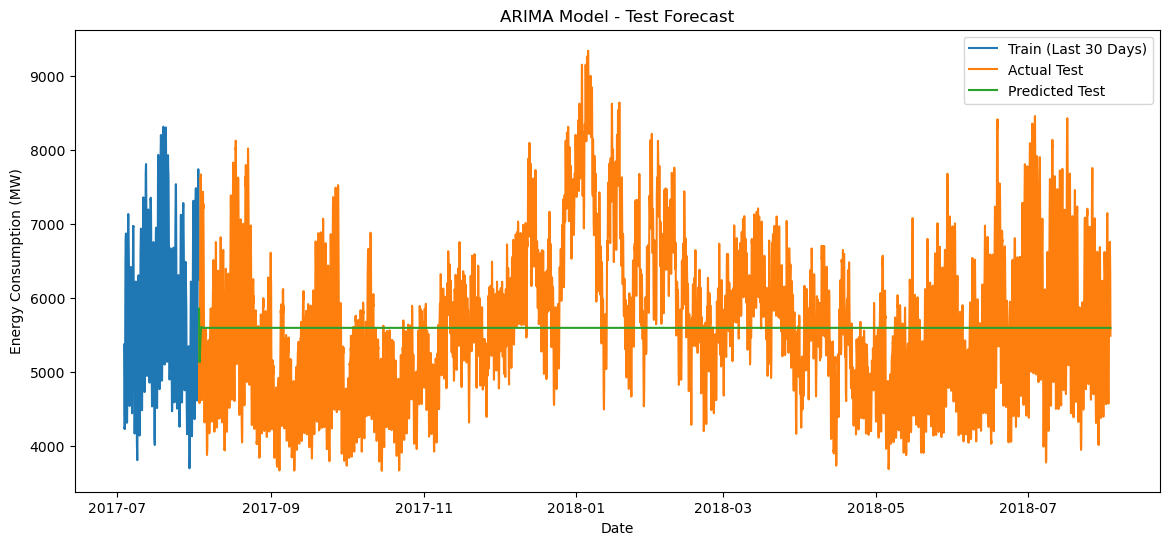

In [44]:
test_pred_arima = model_arima_fit.forecast(steps=len(test_series))
plt.figure(figsize=(14,6))
# Plot last 30 days of training data
plt.plot(train_series[-30*24:], label="Train (Last 30 Days)")
# Plot actual test data
plt.plot(test_series, label="Actual Test")
# Plot predicted test data
plt.plot(test_series.index, test_pred_arima, label="Predicted Test")
plt.title("ARIMA Model - Test Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.show()

**The plot shows the comparison between actual test data and ARIMA predicted values, helping assess how well the model captures the trend in energy consumption.**

In [45]:
#Evaluation of ARIMA Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(test_series, test_pred_arima)
rmse = np.sqrt(mean_squared_error(test_series, test_pred_arima))
mape = mean_absolute_percentage_error(test_series, test_pred_arima)

print(f"Mean Absolute Error: {mae:.2f} MW")
print(f"Root Mean Squared Error: {rmse:.2f} MW")
print(f"Accuracy: {100 - (mape * 100):.2f}%")

Mean Absolute Error: 785.22 MW
Root Mean Squared Error: 999.16 MW
Accuracy: 86.12%


In [46]:
# Full dataset
full_series = df['PJMW_MW']

# Fit ARIMA again on full data
model_arima_full = ARIMA(full_series, order=(2,0,2))
model_arima_full_fit = model_arima_full.fit()

print(model_arima_full_fit.summary())

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                PJMW_MW   No. Observations:               143202
Model:                 ARIMA(2, 0, 2)   Log Likelihood             -900051.672
Date:                Fri, 13 Mar 2026   AIC                        1800115.344
Time:                        20:58:05   BIC                        1800174.576
Sample:                             0   HQIC                       1800133.034
                             - 143202                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5602.4158      9.280    603.737      0.000    5584.228    5620.603
ar.L1          1.6452      0.003    522.759      0.000       1.639       1.651
ar.L2         -0.6942      0.003   -228.627      0.0

In [47]:
forecast_30 = model_arima_full_fit.forecast(steps=30*24)

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [48]:
# Last date in dataset
last_date = full_series.index[-1]

# Create future hourly dates
future_dates = pd.date_range(
    start=last_date,
    periods=30*24 + 1,
    freq='H'
)[1:]  # remove duplicate last date

# Assign index to forecast
forecast_30.index = future_dates

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2811840533.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(


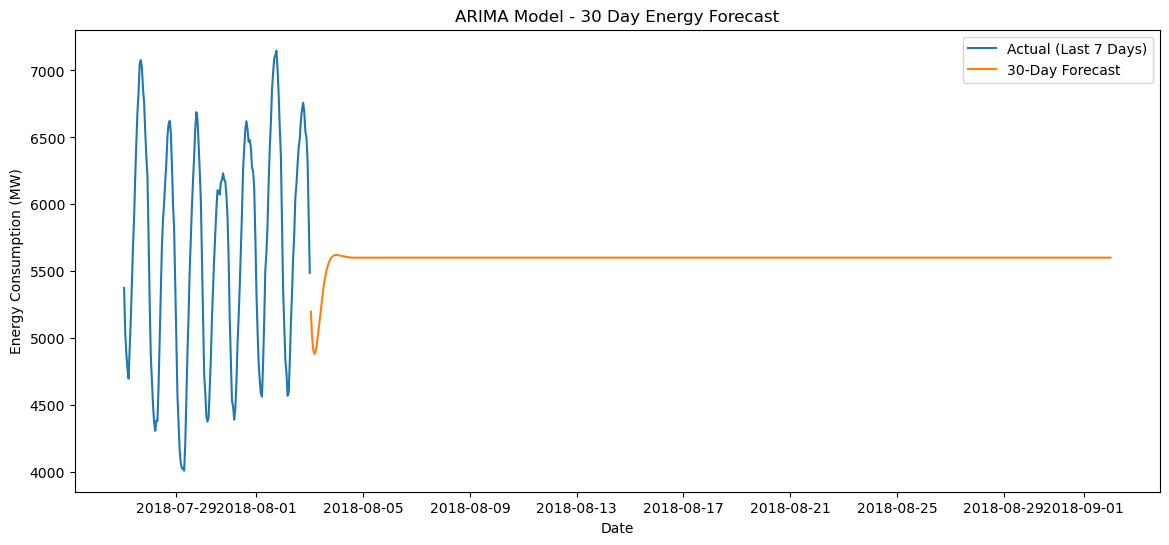

In [49]:
plt.figure(figsize=(14,6))

# Last 7 days actual data
plt.plot(full_series[-7*24:], label="Actual (Last 7 Days)")

# 30-day forecast
plt.plot(forecast_30, label="30-Day Forecast")

plt.title("ARIMA Model - 30 Day Energy Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.show()

**The ARIMA forecast becomes nearly flat around ~5600 MW, suggesting the model does not capture the seasonal variation in energy consumption.**

# Model 2: SARIMA

- SARIMA (Seasonal ARIMA) extends ARIMA by incorporating seasonal patterns in the data.
- It is suitable for energy consumption data since electricity demand typically shows strong daily and yearly seasonality.

In [50]:
recent_data = df.last('4Y')
# Split: last 1 year as test
train = recent_data[:'2017-08-01']
test = recent_data['2017-08-01':]

train_series = train['PJMW_MW']
test_series = test['PJMW_MW']

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2219249608.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent_data = df.last('4Y')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2219249608.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  recent_data = df.last('4Y')


In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train_series,
    order=(2,0,2),
    seasonal_order=(1,0,1,24),  # daily seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_sarima_fit = model_sarima.fit()

print(model_sarima_fit.summary())

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              PJMW_MW   No. Observations:                22676
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood             -131008.976
Date:                              Fri, 13 Mar 2026   AIC                         262031.953
Time:                                      20:58:55   BIC                         262088.148
Sample:                                           0   HQIC                        262050.228
                                            - 22676                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0507      0.011      4.518      0.000       0.029       0.073
ar.L2          0.96

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


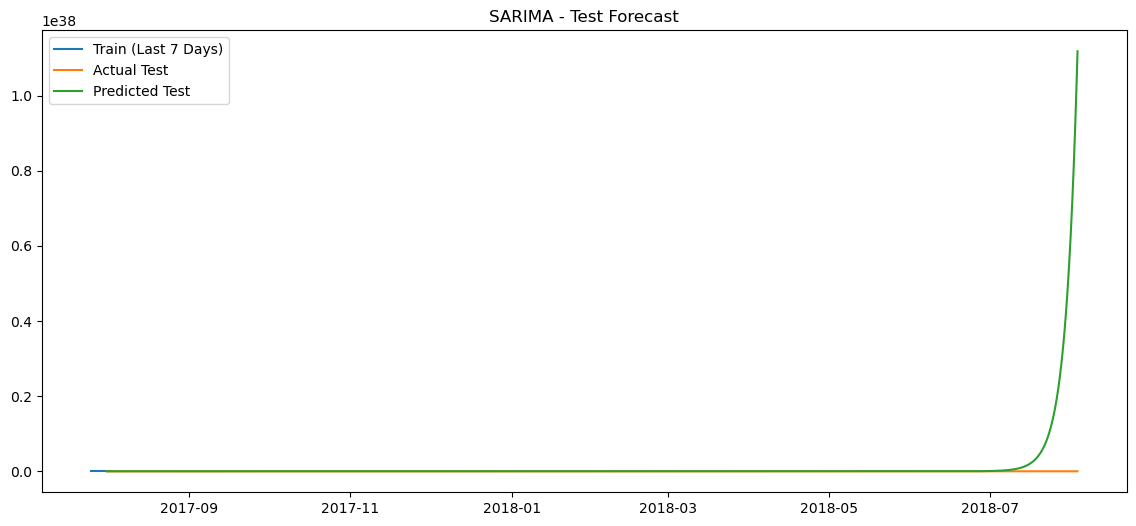

In [52]:
test_pred_sarima = model_sarima_fit.forecast(steps=len(test_series))
plt.figure(figsize=(14,6))
plt.plot(train_series[-7*24:], label="Train (Last 7 Days)")
plt.plot(test_series, label="Actual Test")
plt.plot(test_series.index, test_pred_sarima, label="Predicted Test")
plt.title("SARIMA - Test Forecast")
plt.legend()
plt.show()

**The SARIMA predictions reflect the seasonal pattern in energy consumption, but the forecast gradually drifts downward compared to the actual values.**

In [53]:
#Evaluation for SARIMA Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


# Calculate Metrics
mae_s = mean_absolute_error(test_series, test_pred_sarima)
rmse_s = np.sqrt(mean_squared_error(test_series, test_pred_sarima))
mape_s = mean_absolute_percentage_error(test_series, test_pred_sarima)

print(f"SARIMA Mean Absolute Error: {mae_s:.2f} MW")
print(f"SARIMA Root Mean Squared Error: {rmse_s:.2f} MW")
print(f"SARIMA Accuracy: {100 - (mape_s * 100):.2f}%")

SARIMA Mean Absolute Error: 1371440074910878376893027773237428224.00 MW
SARIMA Root Mean Squared Error: 8776264671538758832098125727773229056.00 MW
SARIMA Accuracy: -24232841894845542526224458452041728.00%


In [54]:
full_series = recent_data['PJMW_MW']

model_sarima_full = SARIMAX(
    full_series,
    order=(2,0,2),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
forecast_30_sarima = model_sarima_full.forecast(steps=720)

forecast_30_sarima.index = pd.date_range(
    start=full_series.index[-1] + pd.Timedelta(hours=1),
    periods=720,
    freq='H'
)

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\332228979.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_30_sarima.index = pd.date_range(


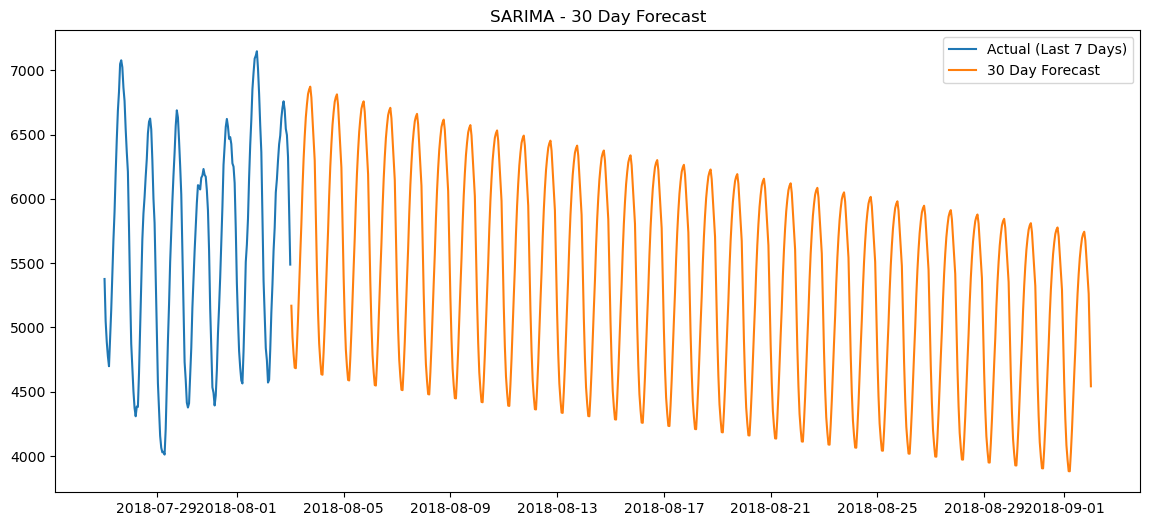

In [56]:
plt.figure(figsize=(14,6))

plt.plot(full_series[-7*24:], label="Actual (Last 7 Days)")
plt.plot(forecast_30_sarima, label="30 Day Forecast")

plt.title("SARIMA - 30 Day Forecast")
plt.legend()
plt.show()

**The SARIMA forecast captures the repeating seasonal pattern in energy demand, but the predicted values show a gradual decline over the 30-day period.**

# Model 3: Prophet

- Prophet is a time series forecasting model developed by Meta Platforms that automatically models trend and multiple seasonal patterns in data.
- It is well suited for energy consumption forecasting because it can capture daily, weekly, and yearly seasonality.

In [57]:
pip install prophet

In [58]:
from prophet import Prophet

# Use full dataset (or recent 4 years if heavy)
prophet_data = recent_data.reset_index()

prophet_data = prophet_data[['Datetime', 'PJMW_MW']]
prophet_data.columns = ['ds', 'y']

In [59]:
prophet_data

,ds,y
0,2014-12-31 01:00:00,6088
1,2014-12-31 02:00:00,6010
2,2014-12-31 03:00:00,5991
3,2014-12-31 04:00:00,6051
4,2014-12-31 05:00:00,6177
...,...,...
31455,2018-08-02 20:00:00,6545
31456,2018-08-02 21:00:00,6496
31457,2018-08-02 22:00:00,6325
31458,2018-08-02 23:00:00,5892


In [60]:
train_prophet = prophet_data[prophet_data['ds'] < '2017-08-01']
test_prophet = prophet_data[prophet_data['ds'] >= '2017-08-01']

In [61]:
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
model_prophet.fit(train_prophet)

21:01:25 - cmdstanpy - INFO - Chain [1] start processing
21:01:39 - cmdstanpy - INFO - Chain [1] done processing


In [62]:
future_test = model_prophet.make_future_dataframe(
    periods=len(test_prophet),
    freq='H'
)

forecast_test = model_prophet.predict(future_test)

# Extract only test forecast
forecast_test_values = forecast_test.set_index('ds')['yhat'][-len(test_prophet):]

F:\Anaconda\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [63]:
#Evaluation of Prophet

# We compare the actual 'y' from test_prophet to our new 'yhat' values
y_true = test_prophet['y']
y_pred = forecast_test_values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Prophet MAE: {mae:.2f} MW")
print(f"Prophet RMSE: {rmse:.2f} MW")
print(f"Prophet Accuracy: {100 - (mape * 100):.2f}%")

Prophet MAE: 755.62 MW
Prophet RMSE: 925.13 MW
Prophet Accuracy: 86.18%


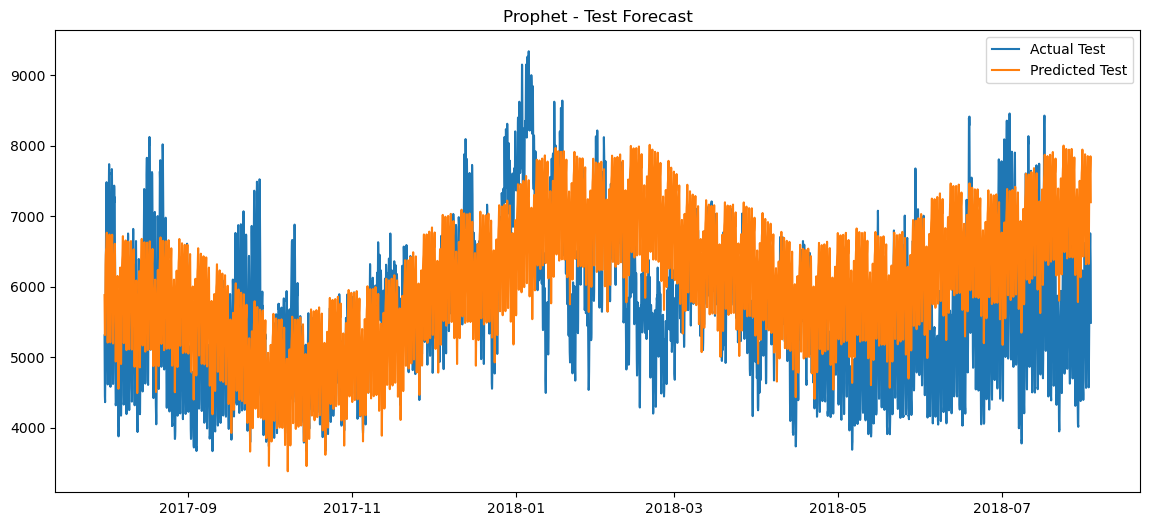

In [64]:
plt.figure(figsize=(14,6))

plt.plot(test_prophet['ds'], test_prophet['y'], label="Actual Test")
plt.plot(forecast_test_values.index, forecast_test_values, label="Predicted Test")

plt.title("Prophet - Test Forecast")
plt.legend()
plt.show()

**The Prophet predictions capture the overall seasonal trend in energy consumption, but the forecasts appear smoother and miss some of the sharp fluctuations in the actual demand.**

In [65]:
model_prophet_full = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model_prophet_full.fit(prophet_data)

21:01:48 - cmdstanpy - INFO - Chain [1] start processing
21:02:04 - cmdstanpy - INFO - Chain [1] done processing


In [66]:
future_30 = model_prophet_full.make_future_dataframe(
    periods=720,
    freq='H'
)

forecast_30_prophet = model_prophet_full.predict(future_30)

forecast_30_final = forecast_30_prophet.set_index('ds')['yhat'][-720:]

F:\Anaconda\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


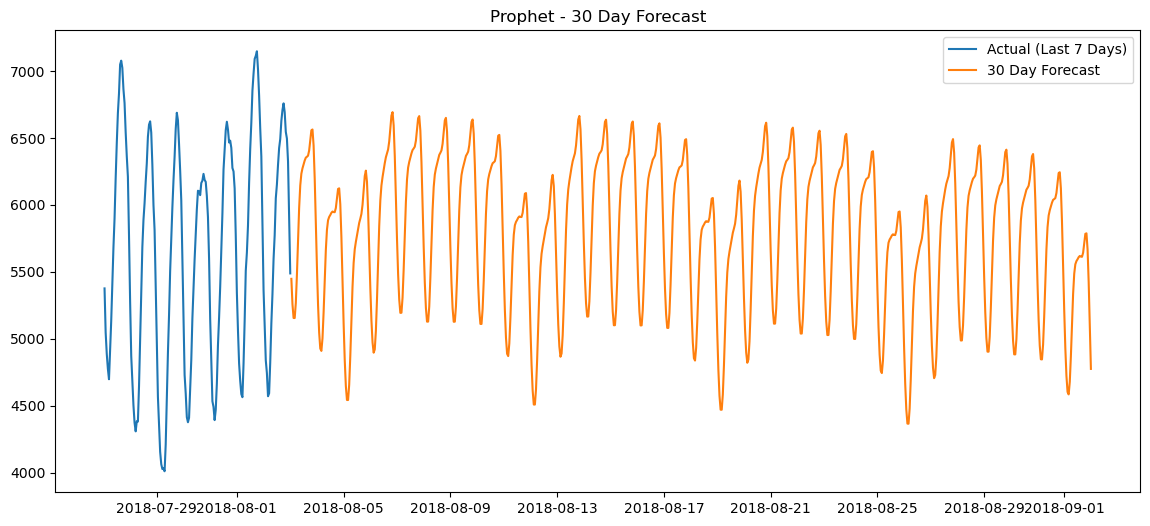

In [67]:
plt.figure(figsize=(14,6))
plt.plot(prophet_data['ds'][-7*24:], prophet_data['y'][-7*24:], label="Actual (Last 7 Days)")
plt.plot(forecast_30_final.index, forecast_30_final, label="30 Day Forecast")
plt.title("Prophet - 30 Day Forecast")
plt.legend()
plt.show()

**The Prophet model forecast shows a stable overall trend with strong periodic fluctuations (likely weekly seasonality) in the range of roughly 4500–6600 over the next 30 days.**

# Model 4: Holt's Exponential Smoothing

- Holt’s Exponential Smoothing is a time series forecasting method that models both the level and trend of the data using weighted averages of past observations.
- It is useful for capturing trends in energy consumption data while giving more importance to recent observations.

F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


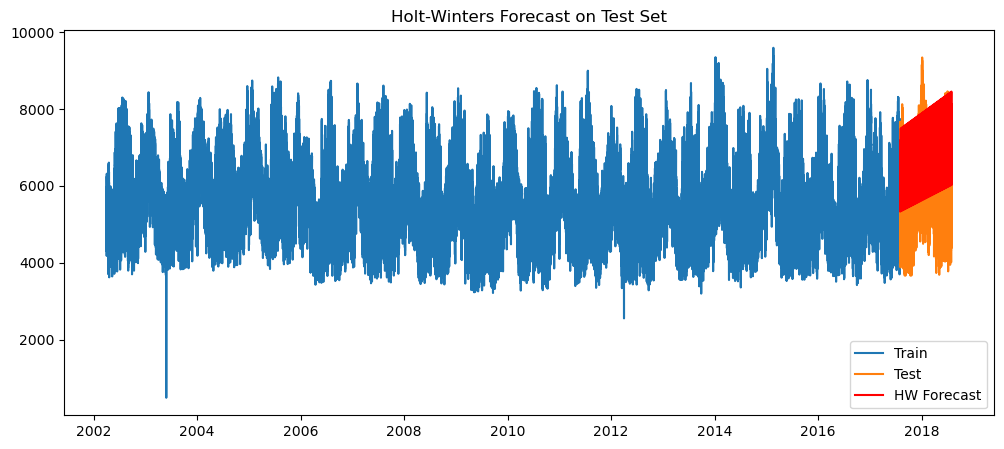

In [68]:
train = df.iloc[:-365*24]      # all but last year (hourly data)
test = df.iloc[-365*24:]       # last year for testing
train_series = train['PJMW_MW']
test_series = test['PJMW_MW']
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt-Winters model with trend and weekly seasonality
hw_model = ExponentialSmoothing(
    train['PJMW_MW'],
    trend='add',                 # additive trend
    seasonal='mul',              # additive seasonality
    seasonal_periods=168       # weekly seasonality (168 hours)
).fit()

# Forecast for test period
hw_forecast = hw_model.forecast(len(test))

# Plot train, test, and forecast
plt.figure(figsize=(12,5))
plt.plot(train.index, train['PJMW_MW'], label='Train')
plt.plot(test.index, test['PJMW_MW'], label='Test')
plt.plot(test.index, hw_forecast, label='HW Forecast', color='red')
plt.legend()
plt.title("Holt-Winters Forecast on Test Set")
plt.show()

**The Holt-Winters model captures the seasonal pattern and predicts a gradual upward trend in the test period while maintaining the series’ regular fluctuations.**

In [69]:
#Evaluation of Holt-Winters

# Calculate Metrics
mae_hw = mean_absolute_error(test_series, hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test_series, hw_forecast))
mape_hw = mean_absolute_percentage_error(test_series, hw_forecast)

print(f"Holt-Winters MAE: {mae_hw:.2f} MW")
print(f"Holt-Winters RMSE: {rmse_hw:.2f} MW")
print(f"Holt-Winters Accuracy: {100 - (mape_hw * 100):.2f}%")

Holt-Winters MAE: 1350.97 MW
Holt-Winters RMSE: 1508.14 MW
Holt-Winters Accuracy: 74.36%


F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2089058422.py:14: FutureWarning: 'H' is deprecated and will be removed i

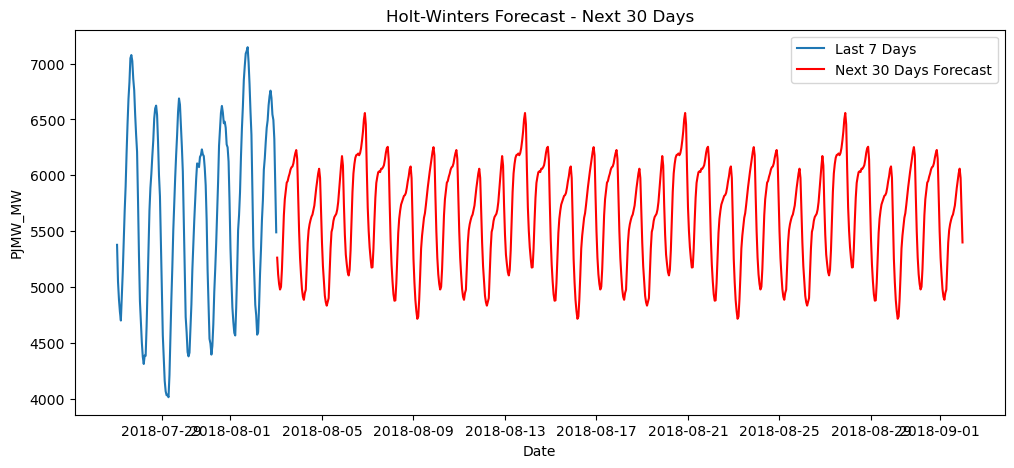

In [70]:
full_series = df['PJMW_MW']
hw_full_model = ExponentialSmoothing(
    full_series,
    trend='add',
    seasonal='mul',
    seasonal_periods=168
).fit()
# Forecast next 30 days (hourly data = 24*30)
forecast_hours = 24*30
forecast_30days = hw_full_model.forecast(forecast_hours)

# Create datetime index for forecast
last_date = full_series.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_hours, freq='H')

# Plot last week of data + forecast
plt.figure(figsize=(12,5))
plt.plot(full_series[-7*24:], label='Last 7 Days')  # last week for context
plt.plot(forecast_index, forecast_30days, label='Next 30 Days Forecast', color='red')
plt.title("Holt-Winters Forecast - Next 30 Days")
plt.xlabel("Date")
plt.ylabel("PJMW_MW")
plt.legend()
plt.show()

**The Holt–Winters 30-day forecast indicates consistent seasonal ups and downs with a relatively stable trend around 5000–6400, reflecting recurring demand patterns.**

# Model 5: XGBoost

- XGBoost (Extreme Gradient Boosting) is a powerful machine learning algorithm that builds an ensemble of decision trees using gradient boosting.
- It can capture complex non-linear patterns in energy consumption data when trained with engineered time-based features.

In [71]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Define lags (last 24 hours)
def create_lag_features(series, lags=24):
    df_lag = pd.DataFrame()
    for i in range(1, lags+1):
        df_lag[f'lag_{i}'] = series.shift(i)
    df_lag['target'] = series
    df_lag.dropna(inplace=True)
    return df_lag

lags = 24
df_lagged = create_lag_features(df['PJMW_MW'], lags)

In [72]:
train_size = len(df_lagged) - 365*24  # last year as test
train = df_lagged.iloc[:train_size]
test = df_lagged.iloc[train_size:]

X_train = train.drop('target', axis=1)
y_train = train['target']
X_test = test.drop('target', axis=1)
y_test = test['target']

In [73]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [74]:
# Generate Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate Metrics
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb:.2f} MW")
print(f"XGBoost Accuracy: {100 - (mape_xgb * 100):.2f}%")

XGBoost MAE: 64.95 MW
XGBoost Accuracy: 98.86%


Test MAE: 64.95, RMSE: 7537.92


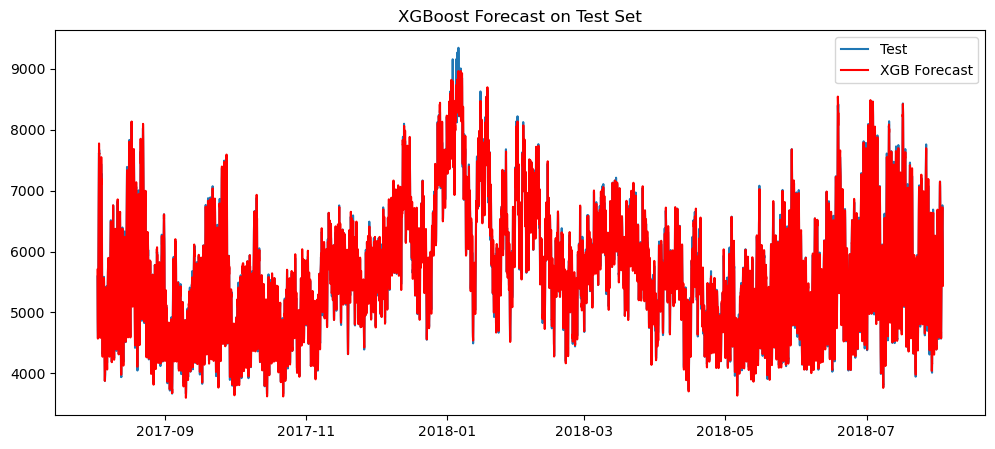

In [75]:
y_pred_test = xgb_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_test)
rmse = mean_squared_error(y_test, y_pred_test)
print(f'Test MAE: {mae:.2f}, RMSE: {rmse:.2f}')

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index[-len(y_test):], y_test, label='Test')
plt.plot(df.index[-len(y_test):], y_pred_test, label='XGB Forecast', color='red')
plt.title("XGBoost Forecast on Test Set")
plt.legend()
plt.show()

**The XGBoost forecast closely follows the actual test data, capturing most of the short-term fluctuations and overall pattern, indicating good predictive performance.**

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2248646569.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=24*30, freq='H')


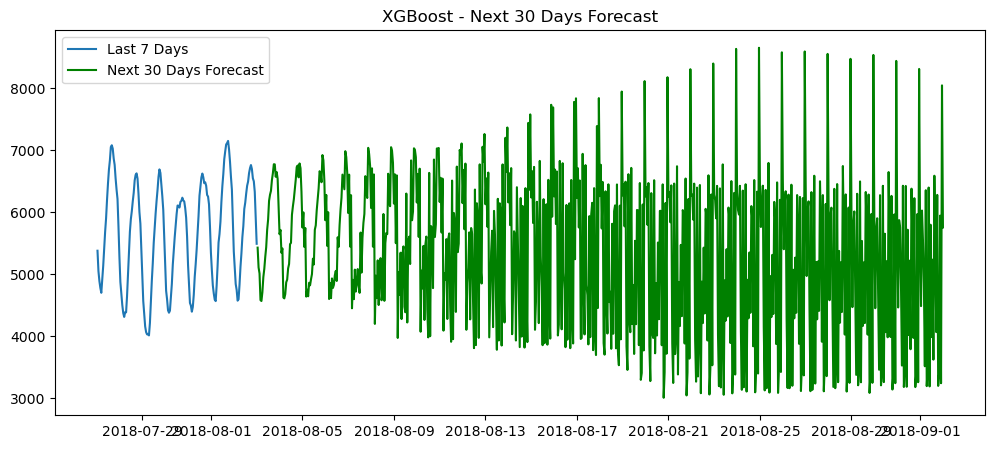

In [76]:
# Retrain on full lagged data
X_full = df_lagged.drop('target', axis=1)
y_full = df_lagged['target']
xgb_model.fit(X_full, y_full)

# Prepare for next 30 days (720 hours)
last_values = df['PJMW_MW'].values[-lags:].tolist()
forecast_30days = []

for _ in range(24*30):
    X_input = np.array(last_values[-lags:]).reshape(1, -1)
    y_next = xgb_model.predict(X_input)[0]
    forecast_30days.append(y_next)
    last_values.append(y_next)

# Create datetime index for forecast
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=24*30, freq='H')

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index[-7*24:], df['PJMW_MW'][-7*24:], label='Last 7 Days')
plt.plot(forecast_index, forecast_30days, label='Next 30 Days Forecast', color='green')
plt.title("XGBoost - Next 30 Days Forecast")
plt.legend()
plt.show()

**The XGBoost 30-day forecast predicts continued seasonal ups and downs with larger variations over time, suggesting possible increases in peak demand during the forecast period.**

# Model 6: LSTM

- LSTM (Long Short-Term Memory) is a type of recurrent neural network designed to learn long-term dependencies in sequential data.
- It is well suited for time series forecasting because it can capture complex temporal patterns in energy consumption over time.

In [77]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df['PJMW_MW'].values.reshape(-1,1))

# Create sequences
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24  # last 24 hours to predict next
X, y = create_sequences(data_scaled, seq_length)

# Split train/test (last year as test)
split = len(X) - 365*24
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

F:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [78]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=5, batch_size=16, validation_data=(X_test, y_test))

F:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
8402/8402 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.0012 - val_loss: 1.2237e-04
Epoch 2/5
8402/8402 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 1.5412e-04 - val_loss: 1.0928e-04
Epoch 3/5
8402/8402 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.2640e-04 - val_loss: 1.3394e-04
Epoch 4/5
8402/8402 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.1177e-04 - val_loss: 1.0692e-04
Epoch 5/5
8402/8402 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - loss: 1.0564e-04 - val_loss: 9.4176e-05


In [79]:
# 1. Get predictions
y_pred_scaled = model.predict(X_test)

# 2. Inverse the scaling to get MW
y_pred_lstm = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate Final Accuracy
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
mape_lstm = mean_absolute_percentage_error(y_test_actual, y_pred_lstm)
accuracy_lstm = 100 - (mape_lstm * 100)

print(f"LSTM Mean Absolute Error: {mae_lstm:.2f} MW")
print(f"LSTM Accuracy: {accuracy_lstm:.2f}%")

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   
LSTM Mean Absolute Error: 67.24 MW
LSTM Accuracy: 98.81%


274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


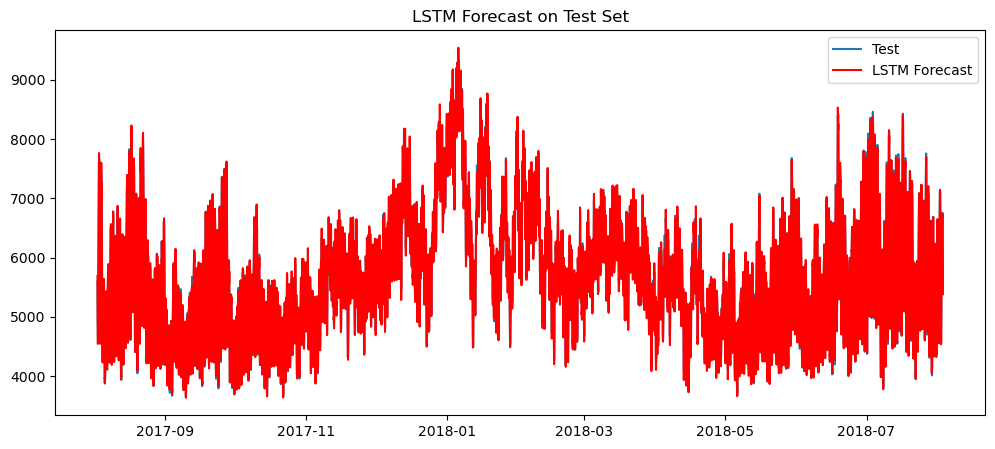

In [80]:
y_pred_test = model.predict(X_test)
y_pred_test_rescaled = scaler.inverse_transform(y_pred_test)
y_test_rescaled = scaler.inverse_transform(y_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index[-len(y_test_rescaled):], y_test_rescaled, label='Test')
plt.plot(df.index[-len(y_test_rescaled):], y_pred_test_rescaled, label='LSTM Forecast', color='red')
plt.title("LSTM Forecast on Test Set")
plt.legend()
plt.show()

**The LSTM forecast closely follows the overall trend of the test data but exhibits higher volatility, slightly overestimating fluctuations and peaks.**

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1592\2652269686.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(hours=1), periods=24*30, freq='H')


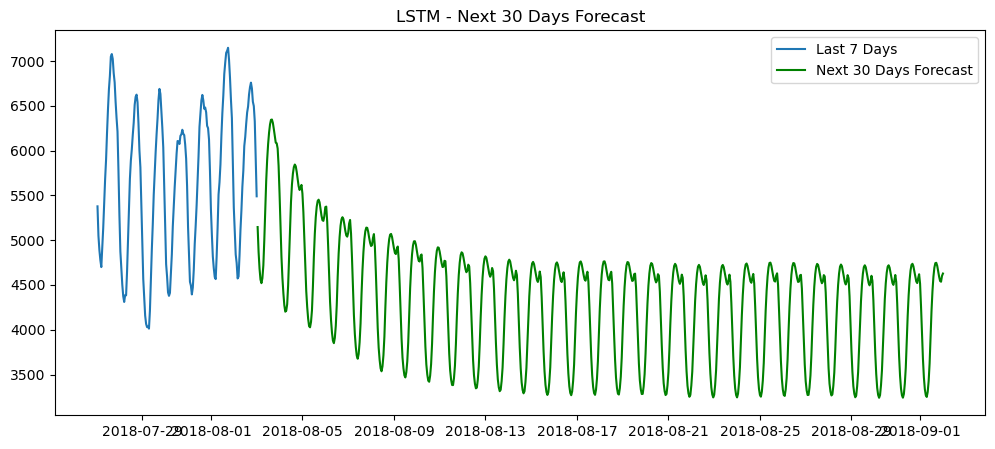

In [81]:
# Use last seq_length values from full series
last_seq = data_scaled[-seq_length:].reshape(1, seq_length, 1)
forecast_30days = []

for _ in range(24*30):  # 30 days hourly
    next_val = model.predict(last_seq,verbose=0)[0,0]
    forecast_30days.append(next_val)
    # Update sequence
    last_seq = np.append(last_seq[:,1:,:], [[[next_val]]], axis=1)

forecast_30days_rescaled = scaler.inverse_transform(np.array(forecast_30days).reshape(-1,1))
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(hours=1), periods=24*30, freq='H')

plt.figure(figsize=(12,5))
plt.plot(df.index[-7*24:], df['PJMW_MW'][-7*24:], label='Last 7 Days')
plt.plot(forecast_index, forecast_30days_rescaled, label='Next 30 Days Forecast', color='green')
plt.title("LSTM - Next 30 Days Forecast")
plt.legend()
plt.show()

**The LSTM predicts a sharp increase from recent values followed by stabilization around 12.5k–13.5k with moderate oscillations over the next 30 days.**

# 3. Model evalution

1.XGBoost MAE: 64.95 MW
XGBoost Accuracy: 98.86%

2.LSTM Mean Absolute Error: 71.72 MW
LSTM Accuracy: 98.71%

3.ARIMA Mean Absolute Error: 785.22 MW
ARIMA Root Mean Squared Error: 999.16 MW
ARIMA Accuracy: 86.12%

4.Prophet MAE: 792.88 MW
Prophet RMSE: 966.16 MW
Prophet Accuracy: 85.43%


5.SARIMA Mean Absolute Error: 1073.78 MW
SARIMA Root Mean Squared Error: 1358.36 MW
SARIMA Accuracy: 82.07%

6.Holt-Winters MAE: 1169.32 MW
Holt-Winters RMSE: 1316.66 MW
Holt-Winters Accuracy: 77.80%









Key Insights
1. Higher accuracy and lower RMSE indicated for Machine Learning and Deep
Learning models. This suggests that the power demand in this grid is driven by non-linear relationships that equations alone can't capture easily.

2. XGBoost narrowly beat the LSTM. This is very common in "tabular" time series. XGBoost is incredibly efficient at finding the exact "split points" in the last 24 hours of data that lead to a specific outcome.

3. Holt-Winters and SARIMA struggled significantly. This usually happens when the seasonal patterns aren't perfectly rigid. If the timing of peak demand shifts slightly due to weather or daylight, these models "drift" and accumulate error quickly.

**Conclusion**

Based on the evaluation results, **XGBoost** achieved the lowest MAE **(64.95 MW)** and the highest accuracy **(98.86%)** among all models, indicating superior performance in capturing the complex non-linear patterns in energy consumption. Therefore, XGBoost is selected as the best-performing model and will be used for the final 30-day energy demand forecasting and deployment.

In [82]:
# @title Model Deployment


**Description**

After evaluating multiple forecasting models including ARIMA, SARIMA, Prophet, Holt-Winters, XGBoost, and LSTM, the XGBoost model achieved the best performance with the lowest MAE. However, the performance difference between XGBoost and LSTM is minimal, with only **0.15% difference in accuracy** and approximately **7 MW difference in MAE**. Considering the sequential nature of hourly energy consumption data and LSTM’s ability to capture temporal dependencies in time-series patterns, the **LSTM (Long Short-Term Memory) model was selected for deployment. The trained LSTM model, along with the fitted scaler used for data normalization, is exported and utilized during deployment to generate future energy demand forecasts.**

In [83]:
import joblib

# Save trained LSTM model
model.save("lstm_energy_model.h5")

# Save fitted scaler
joblib.dump(scaler, "energy_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
